원본 COCO-like JSON
        ↓
① 이미지 ↔ Annotation 매칭 확인
        ↓
② BBox 이상치 검사/처리
        ↓
③ Annotation 누락 7장 검수
        ↓
④ category_id → YOLO class_id(0~55) 변환
        ↓
⑤ Train / Validation 분리
        ↓
⑥ YOLO 라벨 형식으로 변환
        ↓
⑦ processed/에 저장
        ↓
⑧ YOLO 학습

JSON annotation 모으기 
image_id 기준으로 annotation 합치기 
BBox 이상 여부 확인 
category_id → class_id(0~55) 매핑 
COCO BBox → YOLO BBox 변환 
변환 결과 232개 이미지 / 762개 annotation 확인 
→ 이제 Train / Val 분리
.jpg/.png 이미지와 .txt 라벨을 data/processed에 저장
data.yaml 작성
YOLO baseline 학습

여러 JSON 파일에 나뉘어 있던 Annotation들을 image_id라는 공통 키를 기준으로 묶어서, 이미지별로 관리할 수 있는 구조로 재구성했다.

1. 이미지 별 annotation 통합

In [5]:
import os
import json
from collections import defaultdict


annotation_dir = "../data/raw/sprint_ai_project1_data/train_annotations"
image_dir = "../data/raw/sprint_ai_project1_data/train_images"

# 이미지별 정보 저장
image_data = {}

# 모든 JSON 파일 탐색
for root, dirs, files in os.walk(annotation_dir):   #폴더 안의 하위폴더까지 검색
    
    for file in files:

        #JSON 파일만 처리
        if not file.endswith(".json"):
            continue
        
        # JSON 파일 경로 생성
        json_path = os.path.join(root, file)

        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # images 정보 저장
        for image_info in data.get("images", []):
            image_id = image_info["id"]
            if image_id not in image_data:
                image_data[image_id] = {
                    "file_name": image_info["file_name"],
                    "width": image_info["width"],
                    "height": image_info["height"],
                    "annotations": []
                }

        # annotations 정보 저장
        for ann in data.get("annotations", []):
            image_id = ann["image_id"]
            if image_id in image_data:
                image_data[image_id]["annotations"].append(ann)

print("총 이미지 수:", len(image_data))

total_annotations = sum(
    len(info["annotations"]) 
    for info in image_data.values()
)
print("총 annotation 수:", total_annotations)

총 이미지 수: 232
총 annotation 수: 763


2. Bbox 이상 여부 화인

In [6]:
# BBox 이상 여부 확인

invalid_bboxes = []

for image_id, item in image_data.items():

    image_width = item["width"]
    image_height = item["height"]

    for ann in item["annotations"]:

        x, y, w, h = ann["bbox"]

        # BBox가 이미지 영역을 벗어나는지 확인
        if (
            w <= 0
            or h <= 0
            or x < 0
            or y < 0
            or x + w > image_width
            or y + h > image_height
        ):
            invalid_bboxes.append({
                "image_id": image_id,
                "file_name": item["file_name"],
                "bbox": ann["bbox"],
                "image_size": (image_width, image_height),
                "category_id": ann["category_id"]
            })

print("이상한 BBox 개수:", len(invalid_bboxes))

for bbox in invalid_bboxes:
    print(bbox)

이상한 BBox 개수: 1
{'image_id': 239, 'file_name': 'K-003351-016262-018357_0_2_0_2_75_000_200.png', 'bbox': [6567, 625, 311, 315], 'image_size': (976, 1280), 'category_id': 18357}


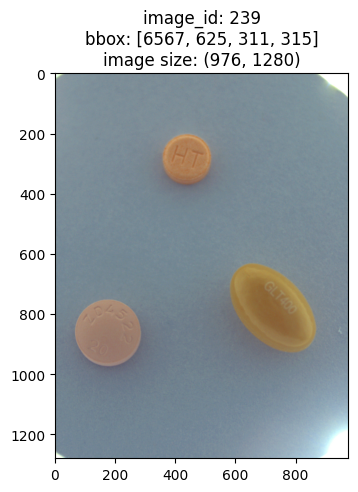

In [8]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

for item in invalid_bboxes:

    image_path = os.path.join(image_dir, item["file_name"])

    image = Image.open(image_path)

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.imshow(image)

    x, y, w, h = item["bbox"]

    rect = patches.Rectangle(
        (x, y),
        w,
        h,
        linewidth=2,
        fill=False
    )

    ax.add_patch(rect)

    ax.set_title(
        f"image_id: {item['image_id']}\n"
        f"bbox: {item['bbox']}\n"
        f"image size: {item['image_size']}"
    )

    plt.show()

3. annotation이 2개인 이미지 찾기

In [13]:
two_ann_images = []

for image_id, item in image_data.items():
    if len(item["annotations"]) == 2:
        two_ann_images.append({
            "image_id": image_id,
            "file_name": item["file_name"],
            "annotations": item["annotations"]
        })

print("Annotation이 2개인 이미지:", len(two_ann_images))

for item in two_ann_images:
    print(
        f"image_id: {item['image_id']}, "
        f"file_name: {item['file_name']}"
    )

Annotation이 2개인 이미지: 7
image_id: 193, file_name: K-003351-013900-021325_0_2_0_2_70_000_200.png
image_id: 1267, file_name: K-003351-013900-036637_0_2_0_2_70_000_200.png
image_id: 783, file_name: K-003351-020014-022074_0_2_0_2_90_000_200.png
image_id: 1383, file_name: K-003351-021325-032310_0_2_0_2_90_000_200.png
image_id: 1432, file_name: K-003351-032310-038162_0_2_0_2_70_000_200.png
image_id: 1405, file_name: K-003351-033880-038162_0_2_0_2_75_000_200.png
image_id: 16, file_name: K-003351-035206-041768_0_2_0_2_70_000_200.png


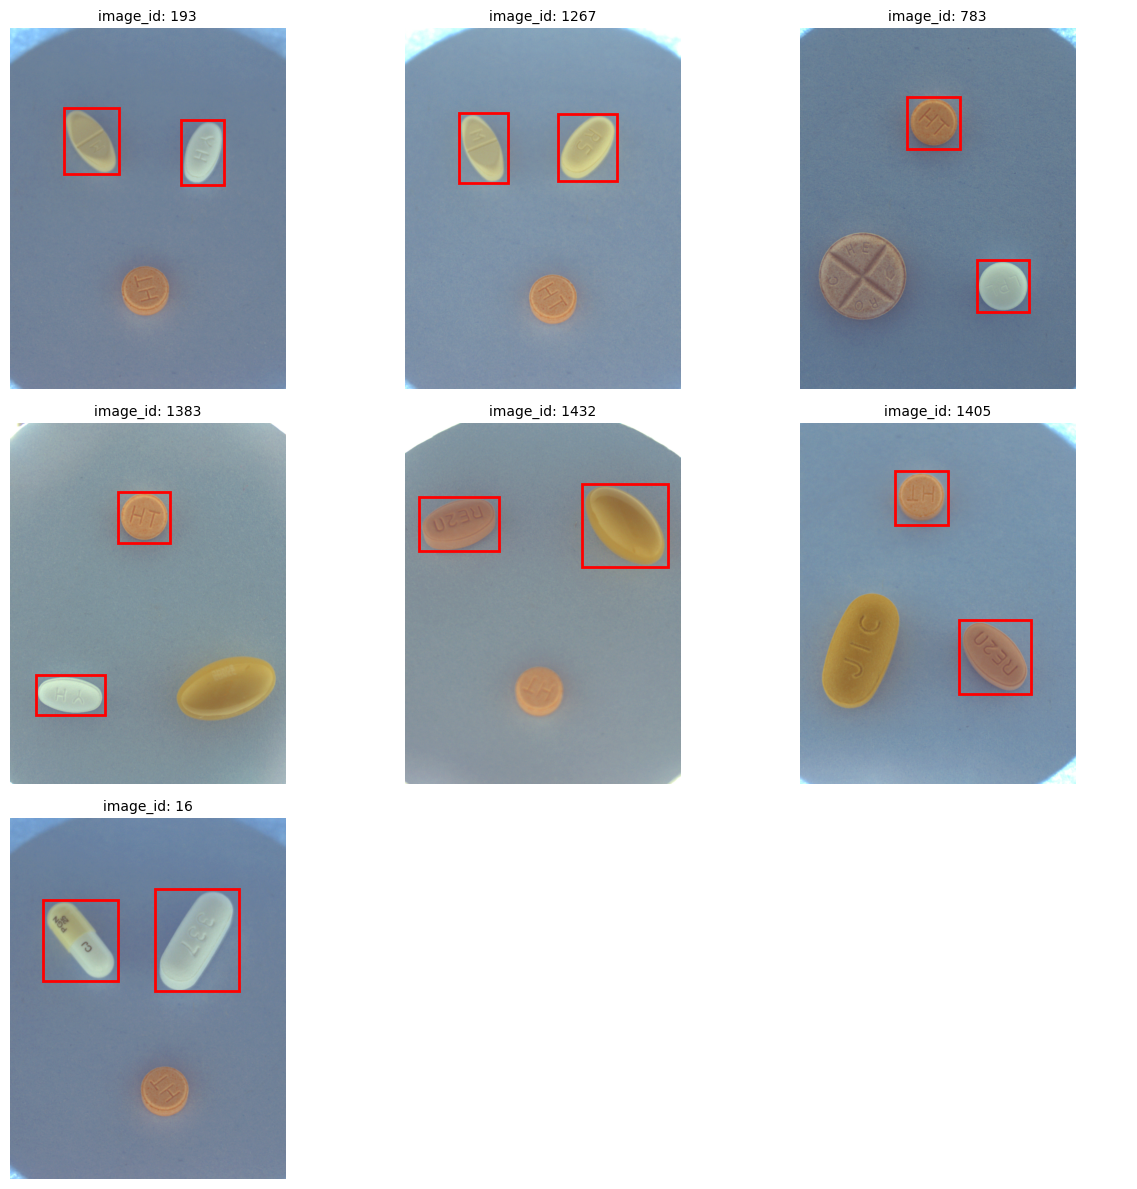

In [15]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax, item in zip(axes, two_ann_images):
    image_path = os.path.join(image_dir, item["file_name"])
    image = Image.open(image_path)

    ax.imshow(image)

    for ann in item["annotations"]:
        x, y, w, h = ann["bbox"]

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

    ax.set_title(f"image_id: {item['image_id']}", fontsize=10)
    ax.axis("off")

# 남는 칸 제거
for ax in axes[len(two_ann_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

4. 클래스 매핑

In [17]:
# 모든 annotation에서 category_id 수집
category_ids = set()

for item in image_data.values():
    for ann in item["annotations"]:
        category_ids.add(ann["category_id"])

print("총 클래스 수:", len(category_ids))

총 클래스 수: 56


In [18]:
category_to_class = {
    category_id: class_id
    for class_id, category_id in enumerate(sorted(category_ids))
}

print("총 클래스 수:", len(category_to_class))

for category_id, class_id in list(category_to_class.items())[:10]:
    print(
        f"category_id: {category_id} → class_id: {class_id}"
    )

총 클래스 수: 56
category_id: 1900 → class_id: 0
category_id: 2483 → class_id: 1
category_id: 3351 → class_id: 2
category_id: 3483 → class_id: 3
category_id: 3544 → class_id: 4
category_id: 3743 → class_id: 5
category_id: 3832 → class_id: 6
category_id: 4543 → class_id: 7
category_id: 12081 → class_id: 8
category_id: 12247 → class_id: 9


5. BBox 변환함수

In [21]:
def convert_bbox_to_yolo(bbox, image_width, image_height):
    x, y, w, h = bbox

    #중심 좌표 계산
    x_center = x + w / 2
    y_center = y + h / 2

    # 0~1 사이로 정규화
    x_center /= image_width
    y_center /= image_height
    w /= image_width
    h /= image_height

    return x_center, y_center, w, h

In [22]:
# 첫 번째 이미지 가져오기
image_id, item = next(iter(image_data.items()))

# 첫 번째 annotation
ann = item["annotations"][0]

yolo_bbox = convert_bbox_to_yolo(
    ann["bbox"],
    item["width"],
    item["height"]
)

class_id = category_to_class[ann["category_id"]]

print("원본 bbox:", ann["bbox"])
print("category_id:", ann["category_id"])
print("class_id:", class_id)
print("YOLO bbox:", yolo_bbox)

원본 bbox: [644, 845, 189, 190]
category_id: 1900
class_id: 0
YOLO bbox: (0.7566598360655737, 0.734375, 0.19364754098360656, 0.1484375)


6. YOLO 라벨 변환

In [23]:
yolo_labels = {}

for image_id, item in image_data.items():
    labels = []

    image_width = item["width"]
    image_height = item["height"]

    for ann in item["annotations"]:
        x, y, w, h = ann["bbox"]

        # 잘못된 BBox 제외
        if (
            w <= 0
            or h <= 0
            or x < 0
            or y < 0
            or x + w > image_width
            or y + h > image_height
        ):
            continue

        # category_id → YOLO class_id
        class_id = category_to_class[ann["category_id"]]

        # YOLO 형식으로 변환
        x_center, y_center, w, h = convert_bbox_to_yolo(
            ann["bbox"],
            image_width,
            image_height
        )

        labels.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} "
            f"{w:.6f} {h:.6f}"
        )

    yolo_labels[image_id] = labels

In [24]:
print("변환된 이미지 수:", len(yolo_labels))
print("변환된 annotation 수:", sum(len(labels) for labels in yolo_labels.values()))

변환된 이미지 수: 232
변환된 annotation 수: 762


In [27]:
for image_id, labels in yolo_labels.items():
    print("image_id:", image_id)
    
    for label in labels:
        print(label)
    
    break

image_id: 34
0 0.756660 0.734375 0.193648 0.148438
15 0.269980 0.717578 0.244877 0.186719
22 0.752561 0.282813 0.158811 0.117188
42 0.311475 0.273438 0.401639 0.206250


7. Train/Val 분리

In [28]:
from sklearn.model_selection import train_test_split

image_ids = sorted(image_data.keys())

train_ids, val_ids = train_test_split(
    image_ids,
    test_size=0.2,
    random_state=42
)

print("전체 이미지 수:", len(image_ids))
print("Train 이미지 수:", len(train_ids))
print("Val 이미지 수:", len(val_ids))

전체 이미지 수: 232
Train 이미지 수: 185
Val 이미지 수: 47


In [ ]:
#Train / Val에 겹치는 이미지가 없는지 확인
print("Train ∩ Val:", len(set(train_ids) & set(val_ids)))
print("Train + Val:", len(train_ids) + len(val_ids))

Train ∩ Val: 0
Train + Val: 232


8. 이미지, YOLO 라벨 저장

In [32]:
from pathlib import Path

processed_dir = Path("../data/processed")

for split in ["train","val"]:
    (processed_dir / "images" / split).mkdir(parents=True, exist_ok=True)
    (processed_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

print("processed 디렉토리 생성 완료")

processed 디렉토리 생성 완료


In [33]:
import shutil

split_ids = {
    "train" : train_ids,
    "val" : val_ids
}

for split, ids in split_ids.items():

    for imgage_id in ids:
        item = image_data[imgage_id]

        #원본 이미지 경로
        src_image = Path(image_dir) / item["file_name"]

        #처리된 이미지 저장 경로
        dst_image = processed_dir / "images" / split / item["file_name"]

        #이미지 복사
        shutil.copy2(src_image, dst_image)

        #YOLO label 저장 경로
        label_name = Path(item["file_name"]).stem + ".txt"
        label_path = processed_dir / "labels" / split / label_name

        #YOLO annotation 작성
        labels = yolo_labels[imgage_id]

        label_path.write_text("\n".join(labels),encoding="utf-8")

print("YOLO 데이터셋 생성 완료")


YOLO 데이터셋 생성 완료


In [34]:
for split in ["train", "val"]:
    image_count = len(list(
        (processed_dir / "images" / split).glob("*")
    ))

    label_count = len(list(
        (processed_dir / "labels" / split).glob("*.txt")
    ))

    print(f"{split}")
    print("  이미지:", image_count)
    print("  라벨:", label_count)

train
  이미지: 185
  라벨: 185
val
  이미지: 47
  라벨: 47


9. data.yml 파일 생성

In [36]:
from pathlib import Path

yaml_path = Path("../data/processed/data.yaml")

names = [f"class_{i}" for i in range(len(category_to_class))]

yaml_text = """path: .
train: images/train
val: images/val

num classes: 56

names:
"""

for i, name in enumerate(names):
    yaml_text += f"  {i}: {name}\n"

yaml_path.write_text(yaml_text, encoding="utf-8")
print("data.yaml 생성 완료")
print(yaml_path)

data.yaml 생성 완료
..\data\processed\data.yaml


10. 전처리 결과 검증

In [37]:
for split in ["train", "val"]:

    image_dir_processed = processed_dir / "images" / split
    label_dir_processed = processed_dir / "labels" / split

    images = sorted(image_dir_processed.glob("*"))
    labels = sorted(label_dir_processed.glob("*.txt"))

    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    print(f"\n{split}")
    print("이미지:", len(images))
    print("라벨:", len(labels))
    print("라벨 없는 이미지:", len(image_stems - label_stems))
    print("이미지만 없는 라벨:", len(label_stems - image_stems))


train
이미지: 185
라벨: 185
라벨 없는 이미지: 0
이미지만 없는 라벨: 0

val
이미지: 47
라벨: 47
라벨 없는 이미지: 0
이미지만 없는 라벨: 0
